<a href="https://colab.research.google.com/github/nazuna-0/WorkSheets_AshwiniTamang/blob/WorkSheet---10/WorkSheet10_AshwiniTamangipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercise 1 – Sentiment Analysis using Naive Bayes (IMDB Dataset)**



* Step 1: Import Libraries
* Step 2: Download Required NLTK Data




In [12]:
# Imports
import nltk, re, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import movie_reviews, stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import *

# Downloads
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Step 3: Load IMDB Dataset

In [13]:
docs = [(" ".join(movie_reviews.words(f)), c)
        for c in movie_reviews.categories()
        for f in movie_reviews.fileids(c)]

df = pd.DataFrame(docs, columns=['review', 'sentiment'])

Step 4: Text Preprocessing

Lowercase, remove punctuation, Tokenization, Stopword removal, Stemming

In [21]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    words = word_tokenize(text)
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

df['processed_review'] = df['review'].apply(preprocess)

Step 5: Train–Test Split (80/20)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

Step 6: Bag-of-Words & Naive Bayes

In [23]:
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

MultinomialNB()

Step 7: Model Evaluation

Accuracy: 0.8025
              precision    recall  f1-score   support

         neg       0.79      0.83      0.81       199
         pos       0.82      0.78      0.80       201

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



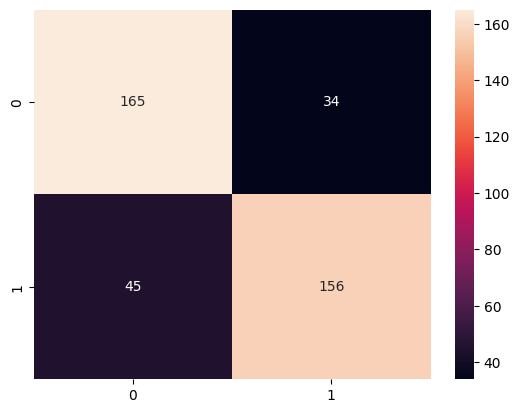

ROC-AUC Score: 0.8651091277281933


In [24]:
y_pred = nb_model.predict(X_test_bow)
y_prob = nb_model.predict_proba(X_test_bow)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

roc_auc = roc_auc_score((y_test == 'pos').astype(int), y_prob)
print("ROC-AUC Score:", roc_auc)

**Exercise 2 – Feature Selection using RFE (Breast Cancer Dataset)**

Step 1: Load Dataset

In [25]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

In [26]:
data = fetch_openml(data_id=35, as_frame=True).frame.dropna()

X = data.iloc[:, :-1]
y = LabelEncoder().fit_transform(data.iloc[:, -1])

Step 2: Data Scaling & Split

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Step 3: RFE – Select Top 5 Features

In [28]:
lr = LogisticRegression(max_iter=1000)
rfe = RFE(lr, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected_features = X.columns[rfe.support_]
print("Top 5 Selected Features:", list(selected_features))


Top 5 Selected Features: ['koebner_phenomenon', 'fibrosis_of_the_papillary_dermis', 'elongation_of_the_rete_ridges', 'vacuolisation_and_damage_of_basal_layer', 'spongiosis']


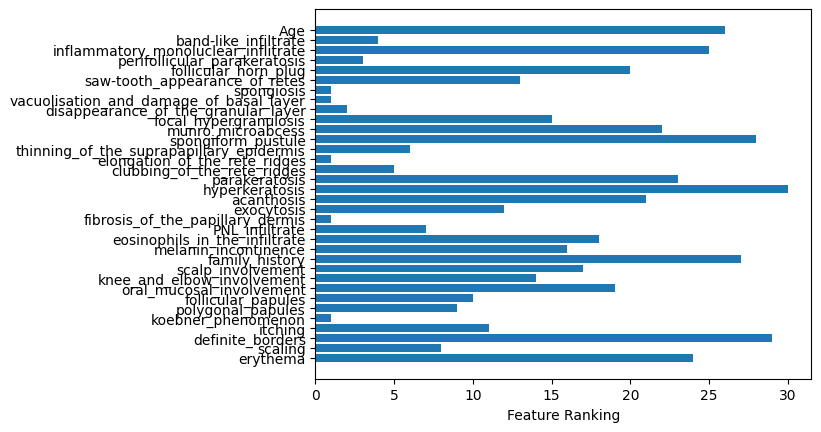

In [29]:
plt.barh(X.columns, rfe.ranking_)
plt.xlabel("Feature Ranking")
plt.show()

Step 4: Model Evaluation (All vs Selected Features)

In [30]:
def evaluate(Xtr, Xte, ytr, yte):
    model = LogisticRegression(max_iter=1000)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return accuracy_score(yte, pred), classification_report(yte, pred)

In [31]:
print("Using All Features:")
print(evaluate(X_train, X_test, y_train, y_test))

print("Using Top 5 Features:")
print(evaluate(rfe.transform(X_train),
               rfe.transform(X_test),
               y_train, y_test))

Using All Features:
(0.9583333333333334, '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        22\n           1       1.00      0.86      0.92        14\n           2       1.00      0.93      0.96        14\n           3       0.73      1.00      0.84         8\n           4       1.00      1.00      1.00        12\n           5       1.00      1.00      1.00         2\n\n    accuracy                           0.96        72\n   macro avg       0.95      0.96      0.95        72\nweighted avg       0.97      0.96      0.96        72\n')
Using Top 5 Features:
(0.9444444444444444, '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        22\n           1       0.82      1.00      0.90        14\n           2       1.00      0.93      0.96        14\n           3       0.88      0.88      0.88         8\n           4       1.00      1.00      1.00        12\n           5       0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
for n in [3, 7]:
    rfe_n = RFE(lr, n_features_to_select=n)
    rfe_n.fit(X_train, y_train)
    acc, _ = evaluate(rfe_n.transform(X_train),
                      rfe_n.transform(X_test),
                      y_train, y_test)
    print(f"Accuracy using top {n} features:", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy using top 3 features: 0.8333333333333334
Accuracy using top 7 features: 0.9861111111111112
